# Metric Exploration
Training curves and ablation results for all PMG classification experiments.

Plot style replicates Guha & Bhandage (2025) — two-panel layout per model:
- **(a)** Training results: accuracy, loss, precision, recall on one axis
- **(b)** Validation results: same four metrics

```
results/metrics/          ← per-epoch train/val/test CSV per run
results/ablation_study/   ← per-checkpoint metrics on black-box occluded test images
```

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE          = Path("../results")
PLOT_DIR      = BASE / "plots"
METRICS_DIR   = BASE / "metrics"
ABLATION_DIR  = BASE / "ablation_study"

C = {
    "accuracy":  "#1f77b4",   # blue
    "loss":      "#d62728",   # red
    "precision": "#2ca02c",   # green
    "recall":    "#ff7f0e",   # orange
    "f1":        "#9467bd",   # purple
    "kappa":     "#8c564b",   # brown
}

plt.rcParams.update({
    "figure.dpi":      120,
    "font.size":       9,
    "axes.linewidth":  0.8,
    "lines.linewidth": 1.4,
})

In [14]:
import plotly.graph_objects as go

PAL = {
    "raw":          "#C0392B",   # muted red
    "preprocessed": "#2471A3",   # steel blue
    "train":        "#1a1a2e",
    "val":          "#457b9d",
    "overfit":      "rgba(220,53,69,0.12)",
    "annotation":   "#555555",
}

LAYOUT_BASE = dict(
    template="plotly_white",
    font=dict(family="Arial", size=12, color="#333333"),
    plot_bgcolor="#FAFAFA",
    paper_bgcolor="white",
    margin=dict(l=60, r=40, t=80, b=60),
)

In [15]:
from pathlib import Path
LOSS_CURVES_DIR   = PLOT_DIR / "loss_curves"
METRIC_CURVES_DIR = PLOT_DIR / "metric_curves"

for d in [LOSS_CURVES_DIR, METRIC_CURVES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## Load all training metrics

In [16]:
def _pretty_label(stem: str) -> str:
    """Turn a filename stem into a readable plot title."""
    stem = stem.replace("_metrics", "")
    parts = stem.split("_")          # e.g. ['resnet101','preprocessed','correct']
    model = parts[0].upper().replace("RESNET", "ResNet-").replace("DENSENET", "DenseNet-")
    data  = parts[1].capitalize()    # Raw / Preprocessed
    mode  = " + ".join(p.capitalize() for p in parts[2:])
    return f"{model}  |  {data}  |  {mode}"


def _run_sort_key(label: str) -> tuple:
    """Sort key: model (resnet→densenet), data (raw→preprocessed),
    downsampled last within group, mode (paper→correct)."""
    parts      = [p.strip() for p in label.split("|")]
    model_str  = parts[0].lower()
    data_str   = parts[1].lower() if len(parts) > 1 else ""
    mode_str   = parts[2].lower() if len(parts) > 2 else ""
    model_rank = 0 if "resnet"      in model_str else 1
    data_rank  = 0 if "raw"         in data_str  else 1
    down_rank  = 1 if "downsampled" in mode_str  else 0
    mode_rank  = 0 if "paper"       in mode_str  else 1
    return (model_rank, data_rank, down_rank, mode_rank)


runs: dict[str, pd.DataFrame] = {}
for csv in sorted(METRICS_DIR.rglob("*.csv")):
    # crossvalidation/ holds fold-level and summary CSVs — handled separately below
    if csv.parent.name == "crossvalidation" or "crossval" in csv.stem:
        continue
    label = _pretty_label(csv.stem)
    runs[label] = pd.read_csv(csv)

runs = dict(sorted(runs.items(), key=lambda kv: _run_sort_key(kv[0])))

print(f"Loaded {len(runs)} runs:\n")
for k, df in runs.items():
    print(f"  {k:<60}  {len(df)} epochs")

Loaded 13 runs:

  ResNet-101  |  Raw  |  Paper                                  20 epochs
  ResNet-101  |  Raw  |  Correct                                20 epochs
  ResNet-101  |  Preprocessed  |  Paper                         20 epochs
  ResNet-101  |  Preprocessed  |  Correct                       20 epochs
  ResNet-101  |  Preprocessed  |  Paper + Downsampled           20 epochs
  ResNet-101  |  Preprocessed  |  Correct + Downsampled         20 epochs
  ResNet-101  |  Preprocessed  |  Correct + Post + Splitdownsampled  20 epochs
  DenseNet-201  |  Raw  |  Paper                                20 epochs
  DenseNet-201  |  Raw  |  Correct                              20 epochs
  DenseNet-201  |  Preprocessed  |  Paper                       20 epochs
  DenseNet-201  |  Preprocessed  |  Correct                     20 epochs
  DenseNet-201  |  Preprocessed  |  Paper + Downsampled         20 epochs
  DenseNet-201  |  Preprocessed  |  Correct + Downsampled       20 epochs


## Training Curves — Paper Style
Each figure replicates the layout of Figs 4–13 in Guha & Bhandage (2025):
- **(a)** Training: accuracy, loss, precision, recall vs epoch
- **(b)** Validation: same four metrics

The red dashed line marks the **best-validation-loss epoch** (checkpoint saved).

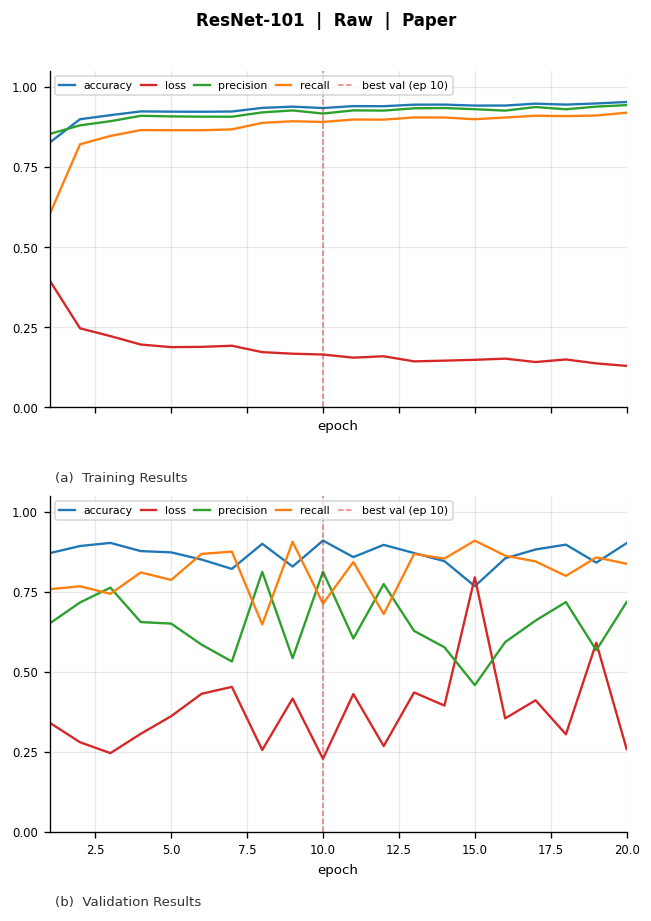

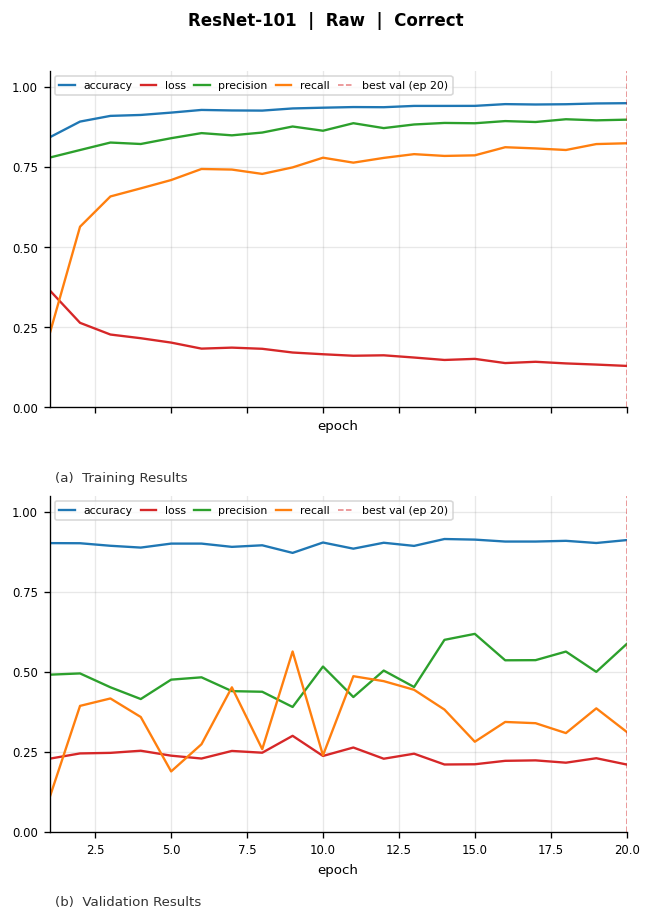

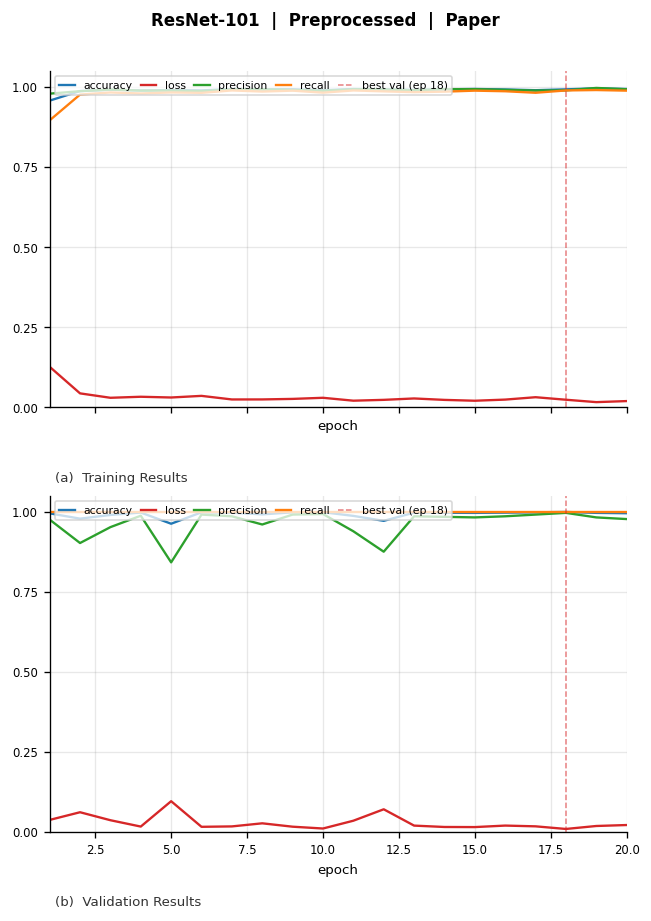

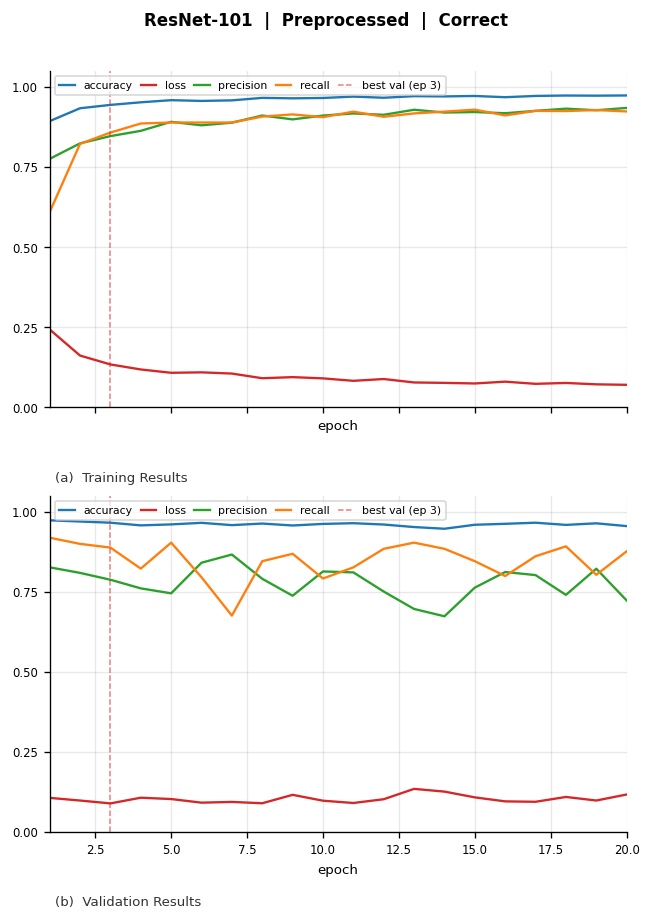

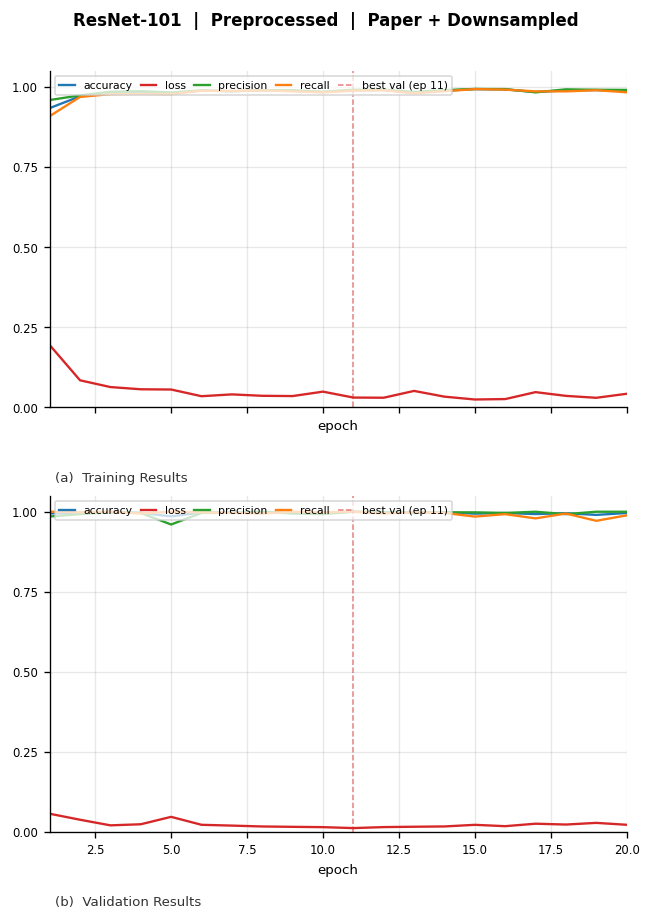

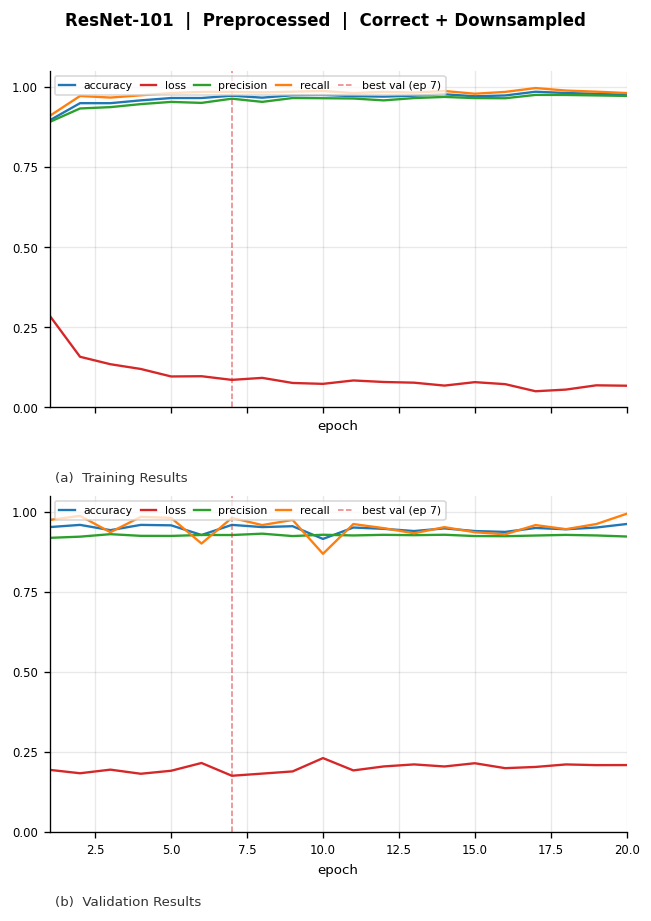

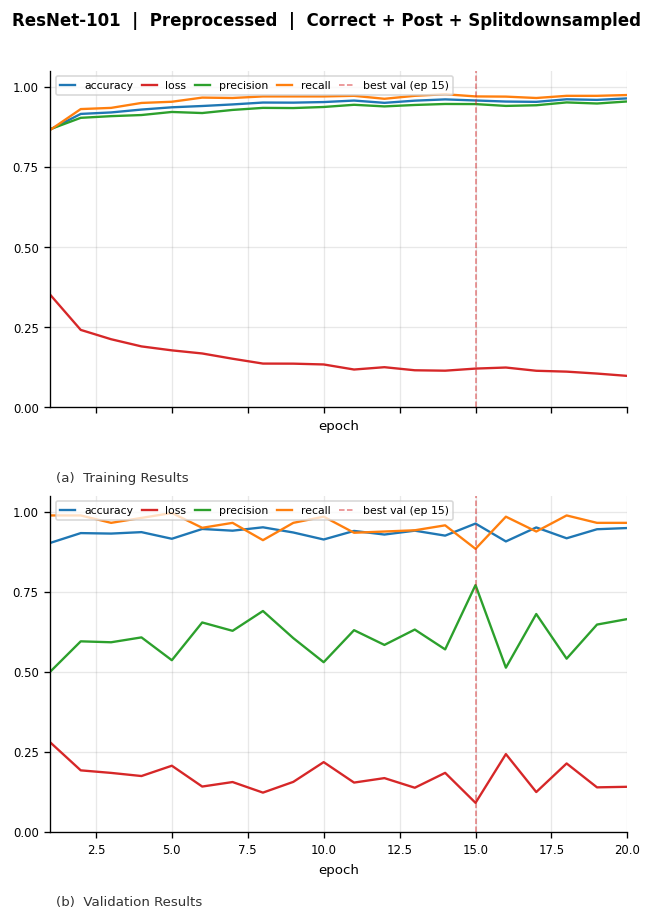

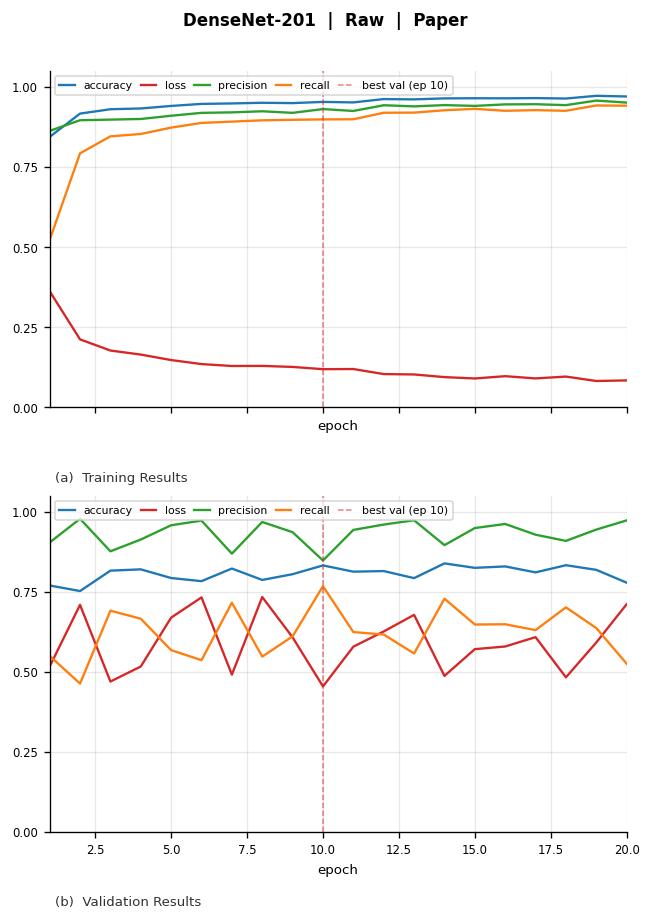

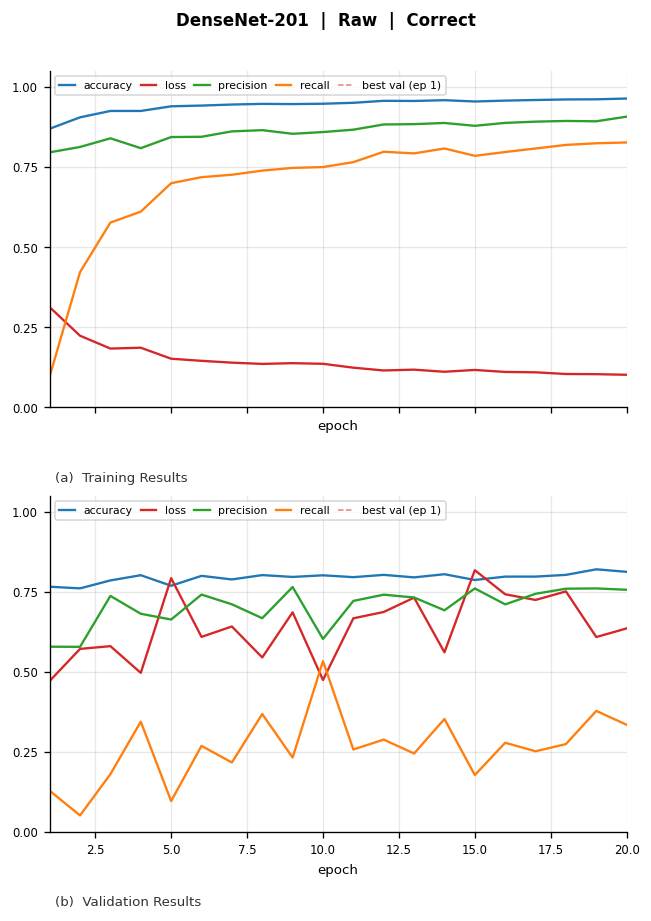

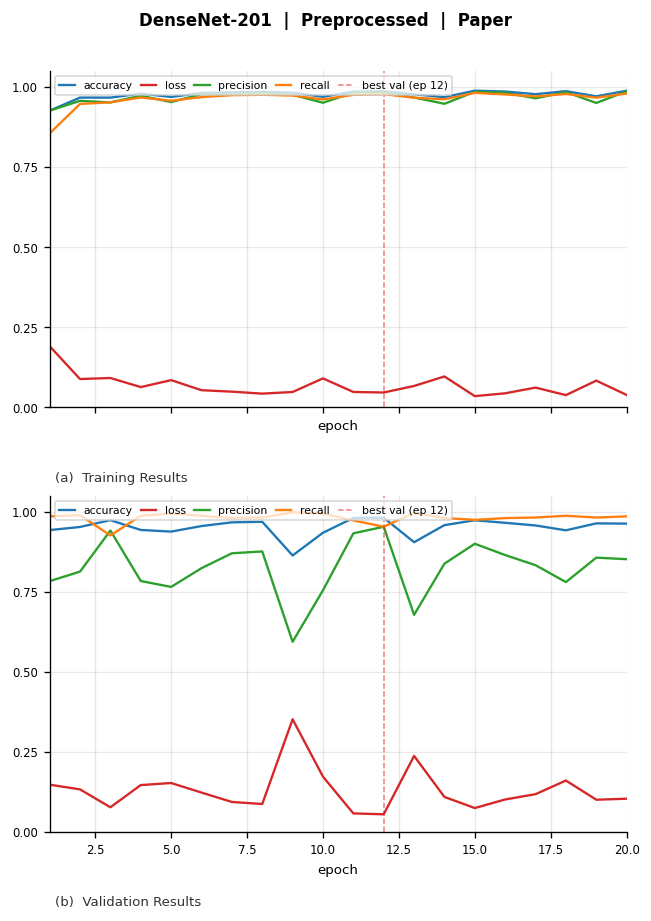

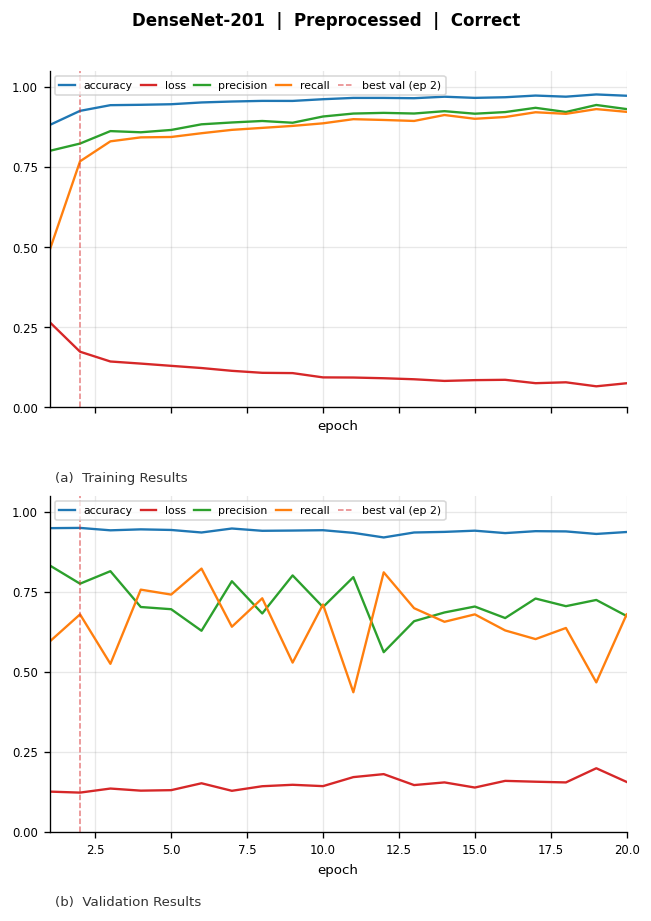

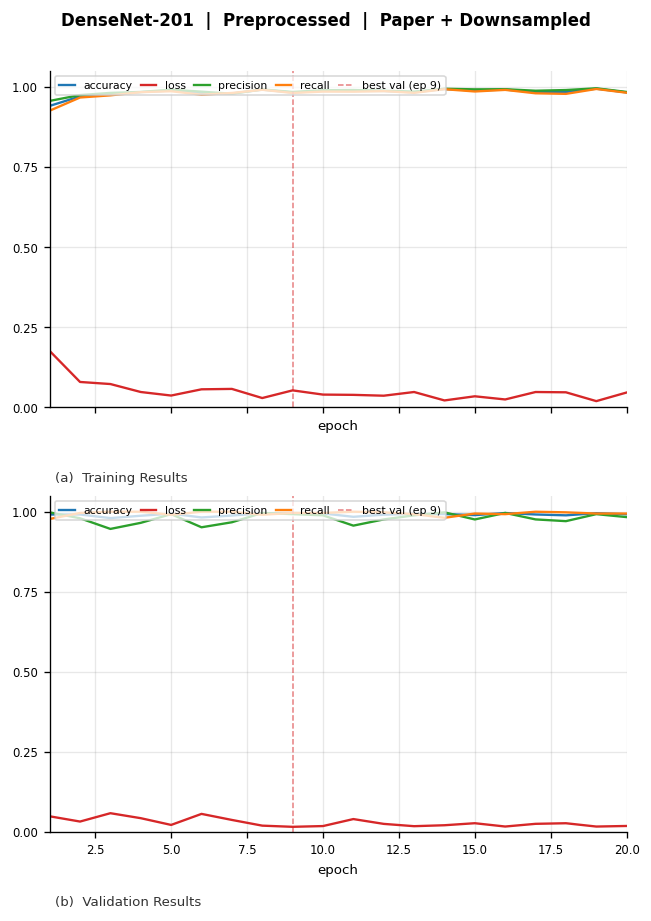

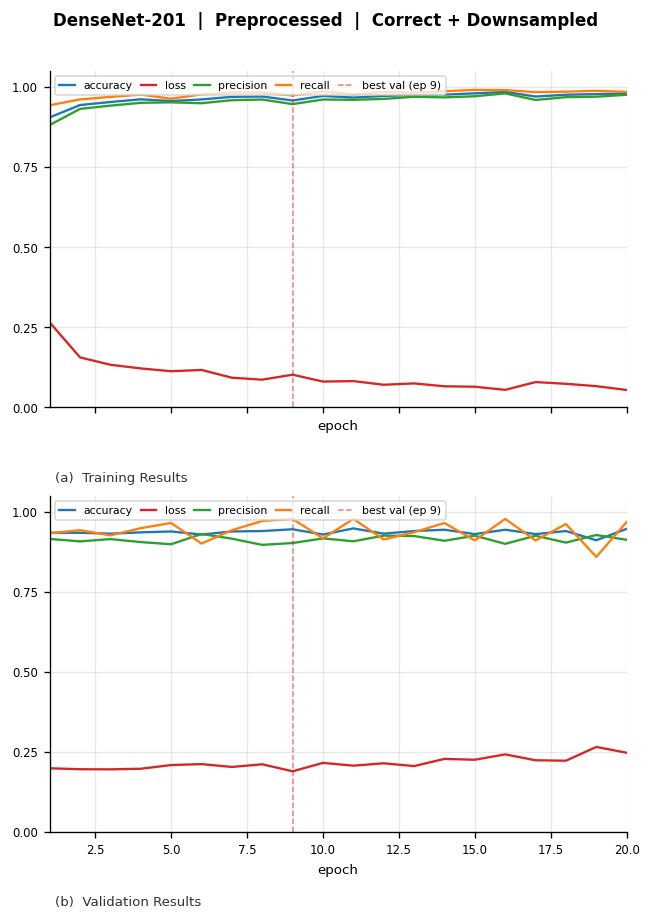

In [17]:
def plot_paper_style(df: pd.DataFrame, title: str, figsize=(5.5, 7.5), save_dir=None) -> None:
    """Two-panel plot replicating Guha & Bhandage (2025) Figs 4-13."""
    best_epoch = df.loc[df["val_loss"].idxmin(), "epoch"]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(title, fontsize=10, fontweight="bold", y=1.01)

    panels = [
        (axes[0], "train", "(a)  Training Results"),
        (axes[1], "val",   "(b)  Validation Results"),
    ]

    for ax, prefix, panel_label in panels:
        ax.plot(df["epoch"], df[f"{prefix}_acc"],       color=C["accuracy"],  label="accuracy")
        ax.plot(df["epoch"], df[f"{prefix}_loss"],      color=C["loss"],      label="loss")
        ax.plot(df["epoch"], df[f"{prefix}_precision"], color=C["precision"], label="precision")
        ax.plot(df["epoch"], df[f"{prefix}_recall"],    color=C["recall"],    label="recall")
        ax.axvline(best_epoch, color="#d62728", lw=0.9, ls="--", alpha=0.6, label=f"best val (ep {best_epoch})")

        ax.set_ylim(0, 1.05)
        ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
        ax.set_xlim(df["epoch"].min(), df["epoch"].max())
        ax.set_xlabel("epoch", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle="-", alpha=0.18, color="grey")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(fontsize=6.5, ncol=5, loc="upper left",
                  framealpha=0.75, handlelength=1.4, columnspacing=0.8)
        ax.text(0.01, -0.22, panel_label, transform=ax.transAxes,
                fontsize=8, ha="left", color="#333333")

    plt.tight_layout()
    if save_dir is not None:
        safe_name = title.replace(" ", "_").replace("/", "-").replace("(", "").replace(")", "").replace(".", "")
        fig.savefig(Path(save_dir) / f"{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


for title, df in runs.items():
    plot_paper_style(df, title, save_dir=LOSS_CURVES_DIR)

## Test Metrics at Best Checkpoint

**Method:** For each training run the epoch with the **lowest validation loss** is
identified and its weights are saved as `_best.pt`. Test metrics are read at that
epoch — not the final epoch — to avoid reporting inflated results from an overfit
endpoint.

**Overfit gap** (train acc − val acc) is computed over all epochs and appended to
the table. A large gap indicates the model memorised the training distribution
rather than learning generalisable features; it is a first-order signal of
shortcut learning or insufficient regularisation.

In [18]:
# ── Collect best-epoch test metrics ───────────────────────────────────────────
records = []
for label, df in runs.items():
    best_idx    = df["val_loss"].idxmin()
    row         = df.loc[best_idx]
    data_type   = label.split("|")[1].strip().lower()
    overfit_gap = round(df["train_acc"].max() - df["val_acc"].max(), 4)
    records.append({
        "run":          label,
        "epoch":        int(row["epoch"]),
        "test_acc":     row["test_acc"],
        "test_prec":    row["test_precision"],
        "test_rec":     row["test_recall"],
        "test_f1":      row["test_f1"],
        "test_kappa":   row["test_kappa"],
        "data_type":    data_type,
        "overfit_gap":  overfit_gap,
    })

summary = pd.DataFrame(records).set_index("run")
display(summary.style
    .format({
        "epoch":       "{:.0f}",
        "test_acc":    "{:.3f}",
        "test_prec":   "{:.3f}",
        "test_rec":    "{:.3f}",
        "test_f1":     "{:.3f}",
        "test_kappa":  "{:.3f}",
        "overfit_gap": "{:.3f}",
    })
    .background_gradient(cmap="YlGn", subset=["test_acc","test_prec","test_rec","test_f1","test_kappa"])
    .set_caption("Test metrics at best-val-loss epoch"))

,epoch,test_acc,test_prec,test_rec,test_f1,test_kappa,data_type,overfit_gap
run,,,,,,,,
ResNet-101 | Raw | Paper,10,0.851,0.747,0.617,0.676,0.580,raw,0.043
ResNet-101 | Raw | Correct,20,0.837,0.259,0.141,0.182,0.100,raw,0.034
ResNet-101 | Preprocessed | Paper,18,0.966,0.882,0.999,0.937,0.914,preprocessed,-0.004
ResNet-101 | Preprocessed | Correct,3,0.896,0.607,0.544,0.573,0.514,preprocessed,0.000
ResNet-101 | Preprocessed | Paper + Downsampled,11,0.992,0.989,0.998,0.994,0.984,preprocessed,-0.007
ResNet-101 | Preprocessed | Correct + Downsampled,7,0.772,0.897,0.625,0.736,0.547,preprocessed,0.023
ResNet-101 | Preprocessed | Correct + Post + Splitdownsampled,15,0.899,0.584,0.756,0.659,0.601,preprocessed,0.001
DenseNet-201 | Raw | Paper,10,0.844,0.580,0.864,0.694,0.595,raw,0.134
DenseNet-201 | Raw | Correct,1,0.870,0.466,0.146,0.222,0.171,raw,0.144


## Best validation loss
## DenseNet-201 
- Test accuracy is relatively high, but for this model and data imbalance it is to be excepted. Its preferable for the model to guess mostly HC, since the HC to cases ratio is 3:1. We see that the precision, recall, F1 and kappa are low. I can try to infer that the model heavy relies on the data imbalance. I cannot conclude any reliance on spetial resolution.


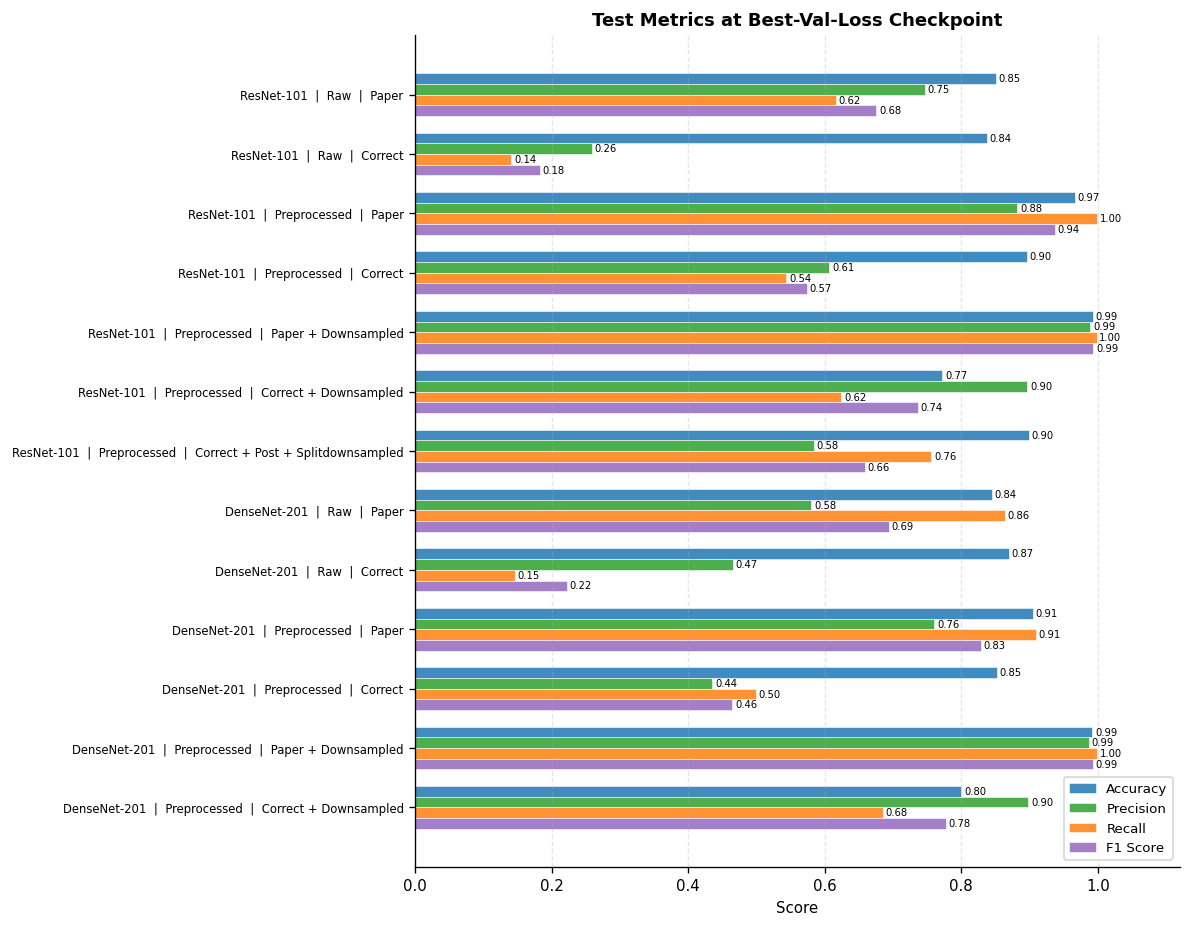

In [19]:
# ── Horizontal grouped bar chart — all runs × 4 key metrics ─────────────────────
metrics_to_plot = [("test_acc",  "Accuracy",  C["accuracy"]),
                   ("test_prec", "Precision", C["precision"]),
                   ("test_rec",  "Recall",    C["recall"]),
                   ("test_f1",   "F1 Score",  C["f1"])]

short_labels = list(summary.index)

n      = len(summary)
y      = np.arange(n)
height = 0.18

fig, ax = plt.subplots(figsize=(10, max(5, n * 0.6)))

for i, (col, lbl, color) in enumerate(metrics_to_plot):
    offsets = y + (i - 1.5) * height
    bars = ax.barh(offsets, summary[col], height, label=lbl,
                   color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.004, bar.get_y() + bar.get_height() / 2,
                f"{w:.2f}", va="center", fontsize=6)

ax.set_yticks(y)
ax.set_yticklabels(short_labels, fontsize=7)
ax.set_xlim(0, 1.12)
ax.set_xlabel("Score")
ax.set_title("Test Metrics at Best-Val-Loss Checkpoint", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(METRIC_CURVES_DIR / "test_metrics_best_checkpoint.png", dpi=150, bbox_inches="tight")
plt.show()

## 5-Fold Cross-Validation

**Method:** The dataset is split into 5 folds at the **patient level** — all slices
from a patient stay within the same fold, preventing data leakage. Each fold is used
once as the held-out test set while the remaining four folds train the model. This
yields 5 independent test evaluations on disjoint patient groups.

Results are shown for four runs:
- **ResNet-101 | Paper setup** — replicating Guha & Bhandage (2025)
- **ResNet-101 | Correct setup** — patient-level split, methodologically sound
- **DenseNet-201 | Paper setup** — replicating Guha & Bhandage (2025)
- **DenseNet-201 | Correct setup** — patient-level split, methodologically sound

Tables mirror **Table 3 in Guha & Bhandage (2025)** (mean ± std across folds).
Bar charts show per-fold values with cross-fold mean (dashed) and ±1 SD (shaded).


In [20]:
CV_DIR = METRICS_DIR / "crossvalidation"

# (folder, model_prefix, display_label)
CV_RUNS = [
    ("Resnet_paper",     "resnet101",   "ResNet-101  |  Paper setup"),
    ("Resnet_correct",   "resnet101",   "ResNet-101  |  Correct setup"),
    ("DenseNet_paper",   "densenet201", "DenseNet-201  |  Paper setup"),
    ("DenseNet_correct", "densenet201", "DenseNet-201  |  Correct setup"),
]

METRICS_CV = ["accuracy", "precision", "recall", "f1", "cohen_kappa"]
LABELS_CV  = ["Accuracy", "Precision", "Recall", "F1", "Cohen's κ"]

cv_data = {}
for folder, model_prefix, label in CV_RUNS:
    fold_path    = CV_DIR / folder / f"{model_prefix}_preprocessed_crossval_per_fold.csv"
    summary_path = CV_DIR / folder / f"{model_prefix}_preprocessed_crossval_summary.csv"
    if fold_path.exists() and summary_path.exists():
        cv_data[label] = {
            "folds":   pd.read_csv(fold_path),
            "summary": pd.read_csv(summary_path, index_col="stat"),
        }
        print(f"Loaded: {label}")
    else:
        print(f"Missing: {label}  (looked in {fold_path})")


Loaded: ResNet-101  |  Paper setup
Loaded: ResNet-101  |  Correct setup
Loaded: DenseNet-201  |  Paper setup
Loaded: DenseNet-201  |  Correct setup


In [21]:
# Styled table per CV run: fold rows + mean±std row
for label, data in cv_data.items():
    df_cv_folds   = data["folds"]
    df_cv_summary = data["summary"]

    rows = []
    for _, r in df_cv_folds.iterrows():
        rows.append({"Fold": f"Fold {int(r['fold'])}", **{l: r[m] for m, l in zip(METRICS_CV, LABELS_CV)}})

    mean_row = {l: df_cv_summary.loc["mean", m] for m, l in zip(METRICS_CV, LABELS_CV)}
    std_row  = {l: df_cv_summary.loc["std",  m] for m, l in zip(METRICS_CV, LABELS_CV)}

    df_tbl = pd.DataFrame(rows).set_index("Fold")
    mean_std_row = {l: f"{mean_row[l]:.3f} ± {std_row[l]:.3f}" for l in LABELS_CV}
    df_mean_std  = pd.DataFrame([mean_std_row], index=["Mean ± Std"])

    display(
        df_tbl.style
        .format("{:.3f}")
        .background_gradient(cmap="YlGn", axis=0)
        .set_caption(f"5-Fold CV test metrics — {label}")
    )
    display(
        df_mean_std.style
        .set_caption(f"Cross-fold summary — {label}")
    )


,Accuracy,Precision,Recall,F1,Cohen's κ
Fold,,,,,
Fold 1,0.993,1.000,0.976,0.988,0.983
Fold 2,0.999,0.996,0.999,0.997,0.997
Fold 3,0.999,0.999,0.997,0.998,0.997
Fold 4,0.992,0.981,0.994,0.988,0.982
Fold 5,0.926,0.994,0.770,0.868,0.817


,Accuracy,Precision,Recall,F1,Cohen's κ
Mean ± Std,0.982 ± 0.031,0.994 ± 0.007,0.947 ± 0.100,0.968 ± 0.056,0.955 ± 0.077


,Accuracy,Precision,Recall,F1,Cohen's κ
Fold,,,,,
Fold 1,0.929,0.702,0.868,0.776,0.734
Fold 2,0.948,0.741,0.838,0.786,0.757
Fold 3,0.947,0.861,0.859,0.860,0.828
Fold 4,0.902,0.756,0.687,0.720,0.661
Fold 5,0.862,0.638,0.474,0.544,0.465


,Accuracy,Precision,Recall,F1,Cohen's κ
Mean ± Std,0.918 ± 0.032,0.739 ± 0.073,0.745 ± 0.151,0.737 ± 0.107,0.689 ± 0.124


,Accuracy,Precision,Recall,F1,Cohen's κ
Fold,,,,,
Fold 1,1.000,1.000,1.000,1.000,1.000
Fold 2,0.997,0.990,1.000,0.995,0.993
Fold 3,0.996,0.988,1.000,0.994,0.991
Fold 4,0.994,0.996,0.986,0.991,0.986
Fold 5,0.914,1.000,0.729,0.843,0.786


,Accuracy,Precision,Recall,F1,Cohen's κ
Mean ± Std,0.980 ± 0.037,0.995 ± 0.006,0.943 ± 0.120,0.965 ± 0.068,0.951 ± 0.092


,Accuracy,Precision,Recall,F1,Cohen's κ
Fold,,,,,
Fold 1,0.929,0.703,0.863,0.775,0.733
Fold 2,0.956,0.772,0.872,0.819,0.794
Fold 3,0.938,0.863,0.797,0.828,0.791
Fold 4,0.916,0.789,0.737,0.762,0.711
Fold 5,0.867,0.634,0.553,0.591,0.512


,Accuracy,Precision,Recall,F1,Cohen's κ
Mean ± Std,0.921 ± 0.034,0.752 ± 0.087,0.764 ± 0.130,0.755 ± 0.096,0.708 ± 0.115


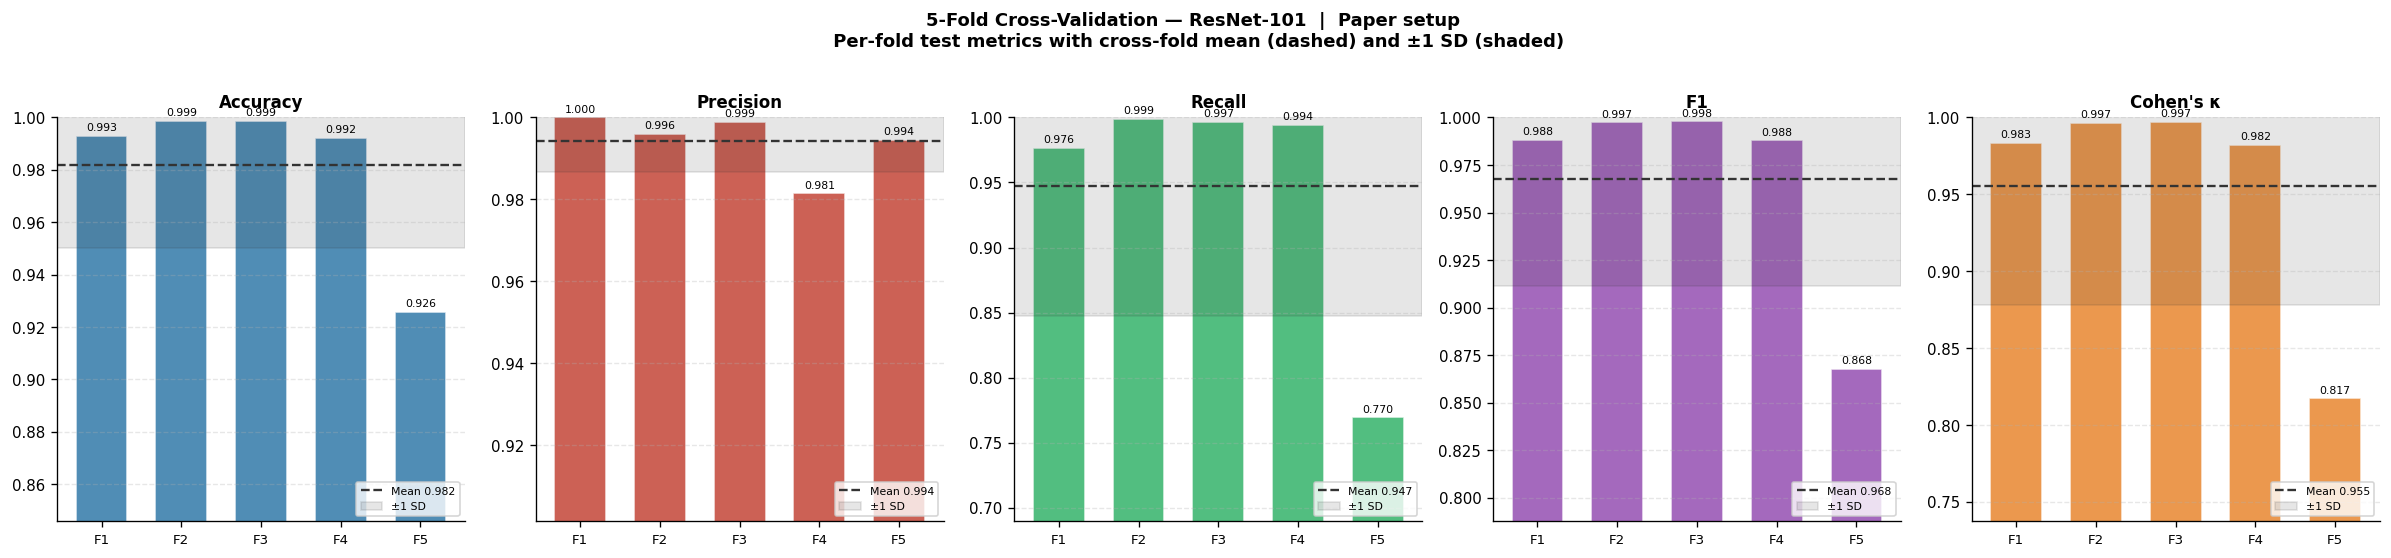

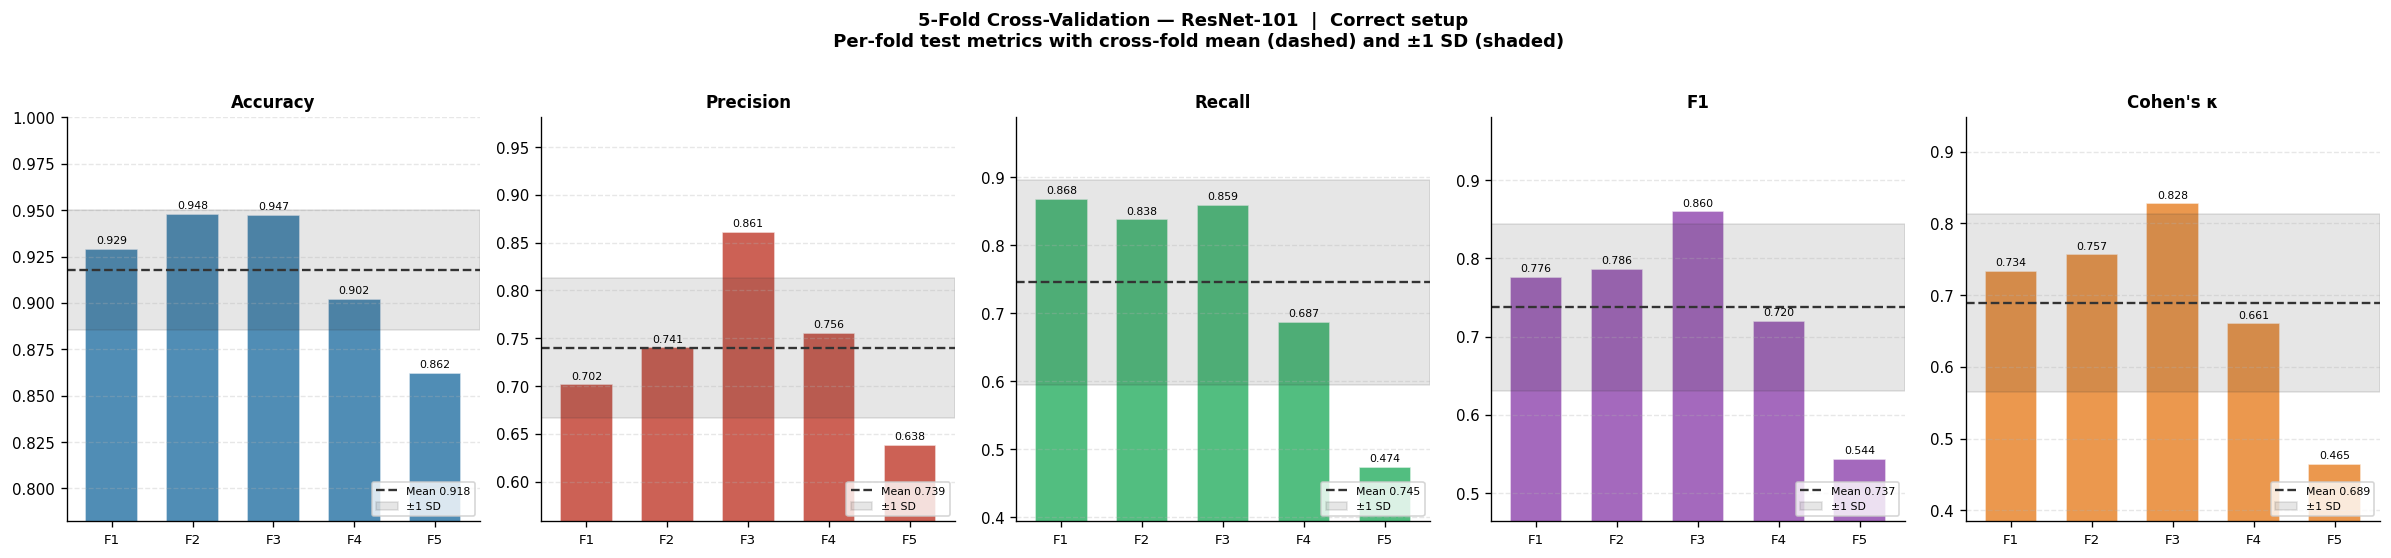

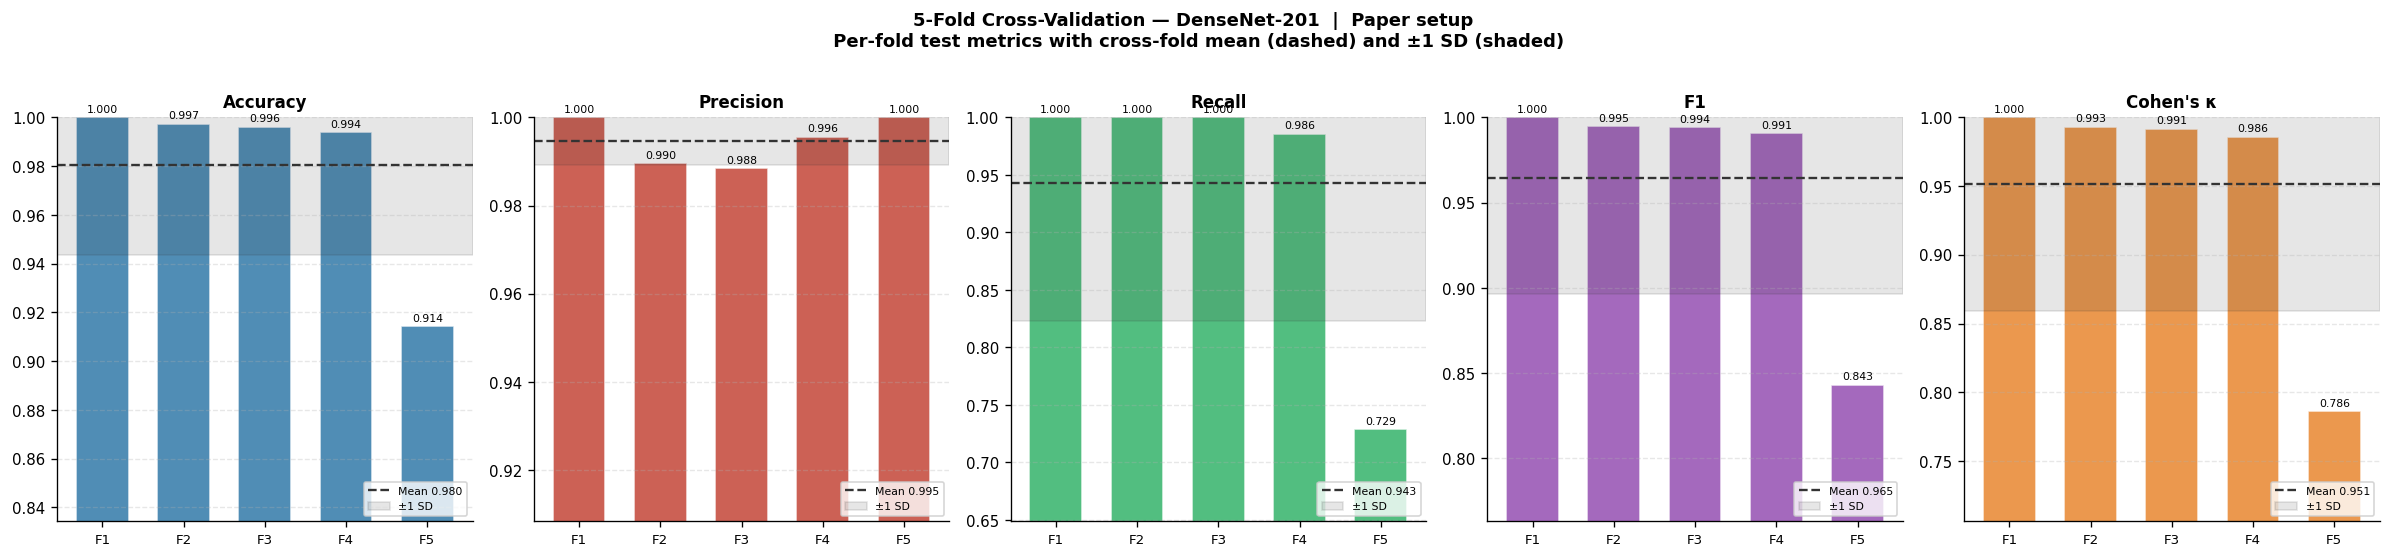

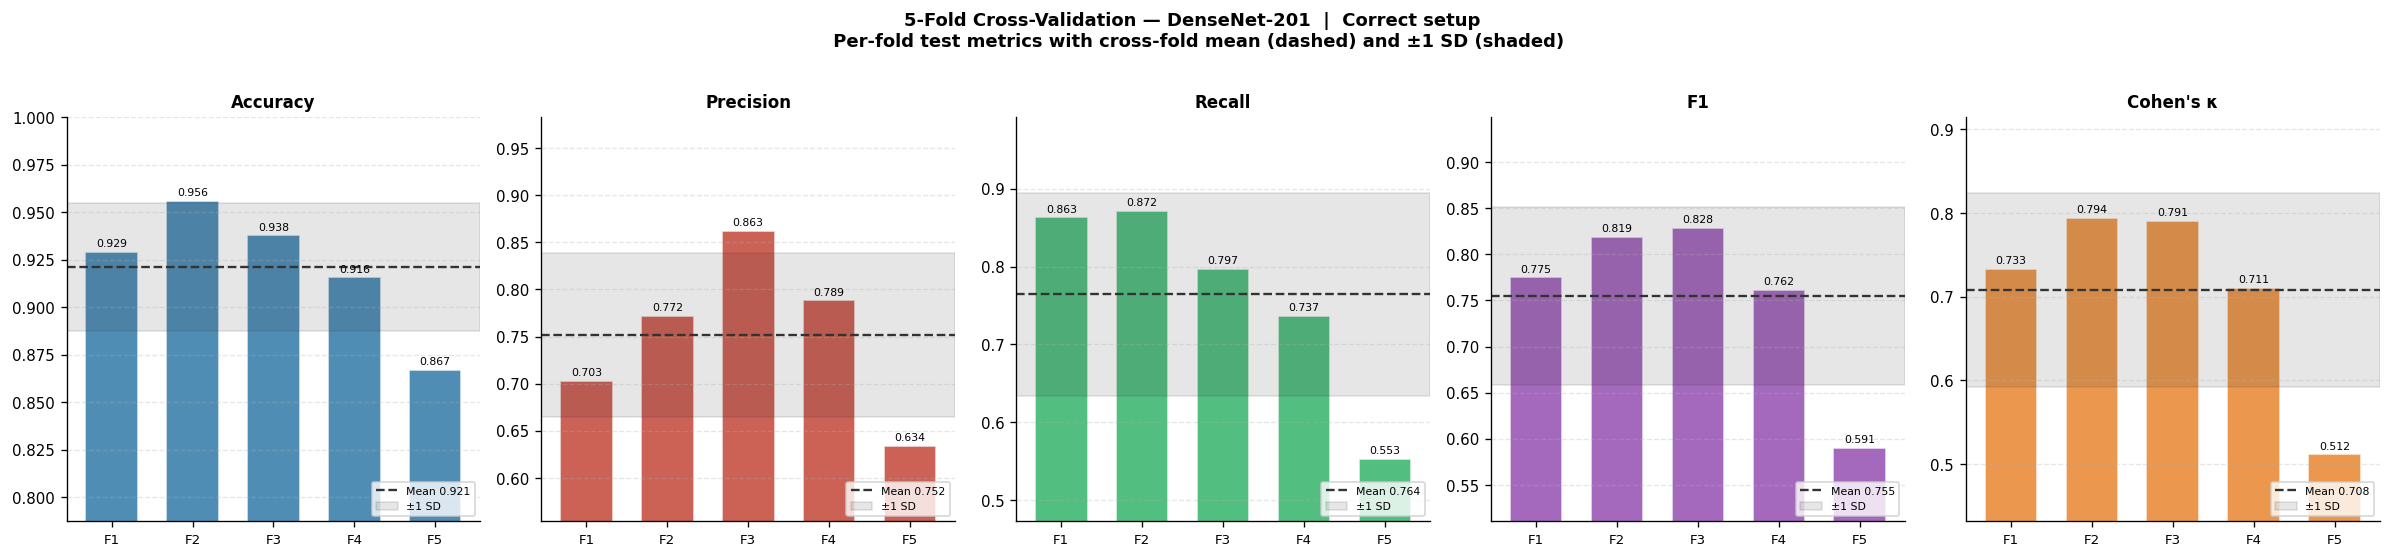

In [22]:
cv_colors = ["#2471A3", "#C0392B", "#27AE60", "#8E44AD", "#E67E22"]

for label, data in cv_data.items():
    df_cv_folds   = data["folds"]
    df_cv_summary = data["summary"]
    folds = df_cv_folds["fold"].astype(int).tolist()
    x     = np.arange(len(folds))

    fig, axes = plt.subplots(1, len(METRICS_CV),
                             figsize=(4 * len(METRICS_CV), 4.5),
                             sharey=False)

    for ax, metric, lbl, color in zip(axes, METRICS_CV, LABELS_CV, cv_colors):
        vals = df_cv_folds[metric].values
        mean = df_cv_summary.loc["mean", metric]
        std  = df_cv_summary.loc["std",  metric]

        bars = ax.bar(x, vals, color=color, alpha=0.80, edgecolor="white", width=0.65)
        ax.bar_label(bars, fmt="%.3f", fontsize=6.5, padding=2)

        ax.axhline(mean, color="#333", lw=1.4, ls="--", label=f"Mean {mean:.3f}")
        ax.axhspan(mean - std, mean + std, alpha=0.12, color="#333", label="±1 SD")

        lo = max(0, min(vals) - 0.08)
        hi = min(1, max(vals) + 0.12)
        ax.set_ylim(lo, hi)
        ax.set_xticks(x)
        ax.set_xticklabels([f"F{f}" for f in folds], fontsize=8)
        ax.set_title(lbl, fontweight="bold", fontsize=10)
        ax.legend(fontsize=6.5, loc="lower right")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    safe_name = label.replace(" ", "_").replace("|", "").replace("-", "").replace("__", "_").strip("_")
    fig.suptitle(
        f"5-Fold Cross-Validation — {label} \n Per-fold test metrics with cross-fold mean (dashed) and ±1 SD (shaded)",  
        fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    fig.savefig(METRIC_CURVES_DIR / f"crossval_{safe_name}_per_fold.png", dpi=150, bbox_inches="tight")
    plt.show()


## Ablation Study — Black-Box Occlusion
Each checkpoint is evaluated on the **test set with a random 20% black-box occlusion** applied to every image.
This tests whether the model learned meaningful brain features or exploited trivial image-level statistics (FOV, resolution).

A model that learned genuine pathological features should drop less on occluded data than one exploiting image-level artefacts.

In [23]:
df_abl = pd.read_csv(ABLATION_DIR / "ablation_results.csv")

# ── Parse checkpoint name into structured columns ─────────────────────────────
def parse_ckpt(name: str) -> dict:
    n = name.replace(".pt", "").replace(".pth", "")
    parts = n.split("_")
    model = parts[0]                           # resnet101 / densenet201
    data  = parts[1]                           # raw / preprocessed
    ckpt  = parts[2]                           # best / final
    mode  = "_".join(parts[3:]) if len(parts) > 3 else ""
    return {"model": model, "data": data, "ckpt_type": ckpt, "mode": mode}

meta = df_abl["checkpoint"].apply(parse_ckpt).apply(pd.Series)
df_abl = pd.concat([df_abl, meta], axis=1)
df_abl["short_label"] = (df_abl["model"] + "\n"
                         + df_abl["data"] + "  "
                         + df_abl["ckpt_type"] + "  "
                         + df_abl["mode"])
df_abl.set_index("checkpoint", inplace=True)
display(df_abl[["accuracy","precision","recall","f1_score"]]
    .style
    .format("{:.3f}")
    .background_gradient(cmap="YlGn")
    .set_caption("Ablation: metrics on black-box occluded test images"))

,accuracy,precision,recall,f1_score
checkpoint,,,,
densenet201_raw_best_correct.pt,0.871,0.759,0.871,0.811
densenet201_raw_best_paper.pt,0.664,0.829,0.664,0.718
densenet201_raw_final_correct.pt,0.876,0.847,0.876,0.837
densenet201_raw_final_paper.pt,0.843,0.830,0.843,0.836
resnet101_preprocessed_best_correct.pt,0.961,0.961,0.961,0.958
resnet101_preprocessed_best_correct_downsampled.pt,0.940,0.944,0.940,0.942
resnet101_preprocessed_best_paper.pt,0.917,0.948,0.917,0.925
resnet101_preprocessed_best_paper_downsampled.pt,0.881,0.934,0.881,0.895
resnet101_preprocessed_final_correct.pt,0.980,0.980,0.980,0.980


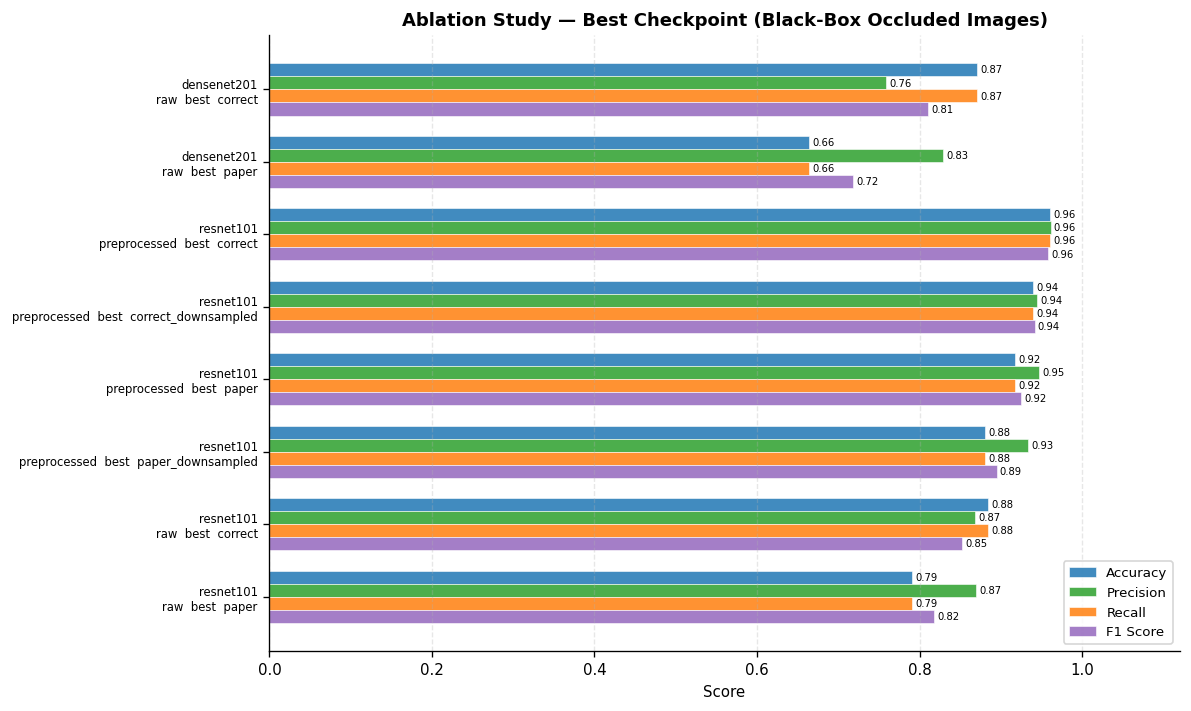

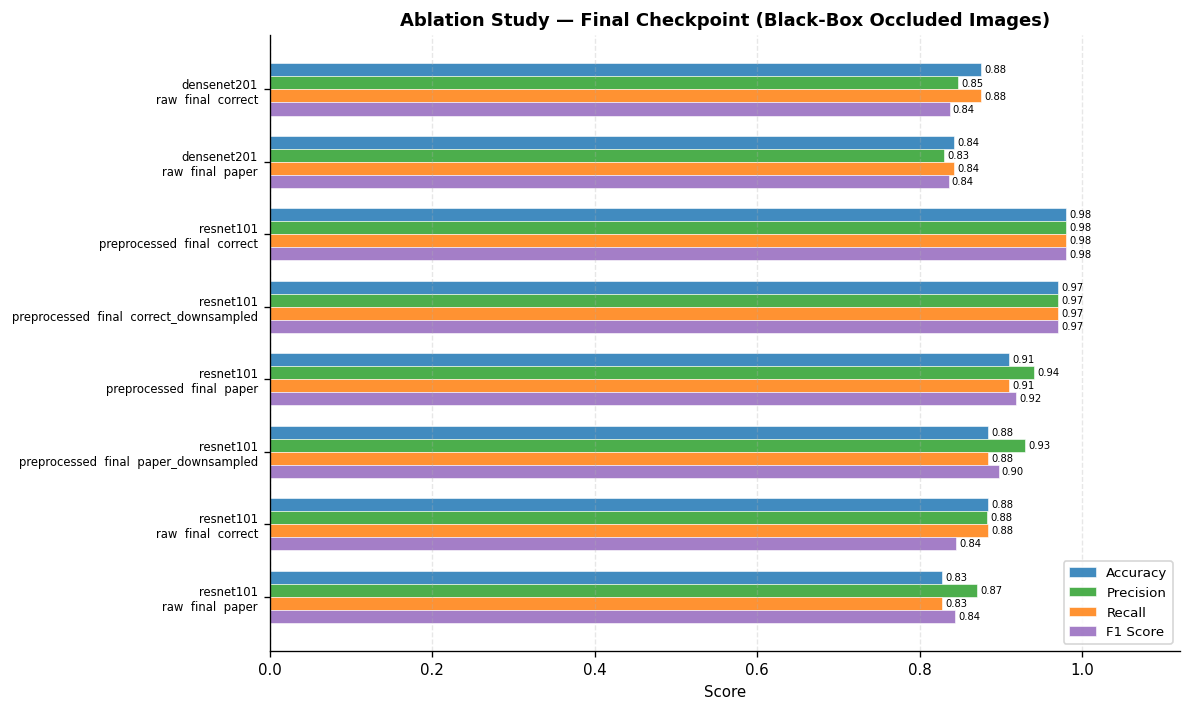

In [24]:
abl_metrics = [("accuracy",  "Accuracy",  C["accuracy"]),
               ("precision", "Precision", C["precision"]),
               ("recall",    "Recall",    C["recall"]),
               ("f1_score",  "F1 Score",  C["f1"])]

height = 0.18

for ckpt_type, title in [
    ("best",  "Ablation Study — Best Checkpoint (Black-Box Occluded Images)"),
    ("final", "Ablation Study — Final Checkpoint (Black-Box Occluded Images)"),
]:
    df_sub = df_abl[df_abl["ckpt_type"] == ckpt_type].copy()
    if df_sub.empty:
        print(f"No {ckpt_type} checkpoints found.")
        continue

    n = len(df_sub)
    y = np.arange(n)

    fig, ax = plt.subplots(figsize=(10, max(6, n * 0.55)))

    for i, (col, lbl, color) in enumerate(abl_metrics):
        offsets = y + (i - 1.5) * height
        bars = ax.barh(offsets, df_sub[col], height,
                       label=lbl, color=color, alpha=0.85,
                       edgecolor="white", linewidth=0.4)
        for bar in bars:
            w = bar.get_width()
            ax.text(w + 0.004, bar.get_y() + bar.get_height() / 2,
                    f"{w:.2f}", va="center", fontsize=6)

    ax.set_yticks(y)
    ax.set_yticklabels(df_sub["short_label"].values, fontsize=7)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Score")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(METRIC_CURVES_DIR / f"ablation_{ckpt_type}_checkpoint.png", dpi=150, bbox_inches="tight")
    plt.show()

In [25]:
import re

def _norm(s: str) -> str:
    """Strip all separator characters and lowercase for comparison."""
    return re.sub(r"[-_ +]", "", s.lower())

def _match_run(run_label: str, model_tag: str, data_tag: str, mode_tag: str) -> bool:
    """Exact per-segment match after normalization."""
    segs = [p.strip() for p in run_label.split("|")]
    run_model = _norm(segs[0]) if len(segs) > 0 else ""
    run_data  = _norm(segs[1]) if len(segs) > 1 else ""
    run_mode  = _norm(segs[2]) if len(segs) > 2 else ""
    return (run_model == _norm(model_tag)
            and run_data == _norm(data_tag)
            and run_mode == _norm(mode_tag))


shortcut_records = []
for ckpt_name, abl_row in df_abl.iterrows():
    model_tag = abl_row["model"]
    data_tag  = abl_row["data"]
    mode_tag  = abl_row["mode"]

    matched_run = None
    for run_label in summary.index:
        if _match_run(run_label, model_tag, data_tag, mode_tag):
            matched_run = run_label
            break

    if matched_run is None:
        continue

    clean_f1    = summary.loc[matched_run, "test_f1"]
    occluded_f1 = abl_row["f1_score"]

    shortcut_records.append({
        "checkpoint":  str(ckpt_name),
        "run":         matched_run,
        "ckpt_type":   abl_row["ckpt_type"],
        "data_type":   summary.loc[matched_run, "data_type"],
        "clean_f1":    clean_f1,
        "occluded_f1": occluded_f1,
        "delta":       clean_f1 - occluded_f1,
    })

df_shortcut = pd.DataFrame(shortcut_records)
print(df_shortcut)

                                           checkpoint  \
0                     densenet201_raw_best_correct.pt   
1                       densenet201_raw_best_paper.pt   
2                    densenet201_raw_final_correct.pt   
3                      densenet201_raw_final_paper.pt   
4              resnet101_preprocessed_best_correct.pt   
5   resnet101_preprocessed_best_correct_downsample...   
6                resnet101_preprocessed_best_paper.pt   
7    resnet101_preprocessed_best_paper_downsampled.pt   
8             resnet101_preprocessed_final_correct.pt   
9   resnet101_preprocessed_final_correct_downsampl...   
10              resnet101_preprocessed_final_paper.pt   
11  resnet101_preprocessed_final_paper_downsampled.pt   
12                      resnet101_raw_best_correct.pt   
13                        resnet101_raw_best_paper.pt   
14                     resnet101_raw_final_correct.pt   
15                       resnet101_raw_final_paper.pt   

                              

### Method Note — Leaderboard

**Best checkpoint** = weights saved at the epoch with minimum validation loss.
**Final checkpoint** = weights after the last training epoch (may be more overfit).

Runs are ranked by **Test F1 descending**. The *Overfit Gap* (peak train acc − best val acc)
and *Occlusion Drop* (clean F1 − occluded F1) columns expose whether high F1 is driven by
genuine learning or by advantageous data setup. If the pattern holds — higher F1 correlates
with larger gap and larger drop — the model's performance reflects data privilege, not
generalisable feature extraction.

In [26]:
def _cheat_table(df_sub: pd.DataFrame, caption: str) -> None:
    """Display a styled leaderboard for one checkpoint type."""
    if df_sub.empty:
        print(f"{caption} — no data")
        return
    tbl = (
        df_sub
        .merge(summary[["overfit_gap", "test_f1"]], left_on="run", right_index=True)
        .drop_duplicates(subset=["run"])
        .sort_values("test_f1", ascending=False)
        .rename(columns={
            "test_f1":    "Test F1",
            "overfit_gap": "Overfit Gap",
            "delta":       "Occlusion Drop",
        })
        [["run", "data_type", "Test F1", "Overfit Gap", "Occlusion Drop"]]
    )
    display(
        tbl.style
        .background_gradient(
            subset=["Test F1", "Overfit Gap", "Occlusion Drop"], cmap="RdYlGn_r"
        )
        .format({"Test F1": "{:.3f}", "Overfit Gap": "{:.3f}", "Occlusion Drop": "{:.3f}"})
        .set_caption(caption)
    )

_cheat_table(
    df_shortcut[df_shortcut["ckpt_type"] == "best"],
    "Best checkpoint — sorted by Test F1 (deeper red = more concerning)",
)
_cheat_table(
    df_shortcut[df_shortcut["ckpt_type"] == "final"],
    "Final checkpoint — sorted by Test F1 (deeper red = more concerning)",
)

,run,data_type,Test F1,Overfit Gap,Occlusion Drop
7,ResNet-101 | Preprocessed | Paper + Downsampled,preprocessed,0.994,-0.007,0.099
6,ResNet-101 | Preprocessed | Paper,preprocessed,0.937,-0.004,0.012
5,ResNet-101 | Preprocessed | Correct + Downsampled,preprocessed,0.736,0.023,-0.205
1,DenseNet-201 | Raw | Paper,raw,0.694,0.134,-0.024
13,ResNet-101 | Raw | Paper,raw,0.676,0.043,-0.142
4,ResNet-101 | Preprocessed | Correct,preprocessed,0.573,0.000,-0.385
0,DenseNet-201 | Raw | Correct,raw,0.222,0.144,-0.589
12,ResNet-101 | Raw | Correct,raw,0.182,0.034,-0.670


,run,data_type,Test F1,Overfit Gap,Occlusion Drop
11,ResNet-101 | Preprocessed | Paper + Downsampled,preprocessed,0.994,-0.007,0.097
10,ResNet-101 | Preprocessed | Paper,preprocessed,0.937,-0.004,0.019
9,ResNet-101 | Preprocessed | Correct + Downsampled,preprocessed,0.736,0.023,-0.234
3,DenseNet-201 | Raw | Paper,raw,0.694,0.134,-0.142
15,ResNet-101 | Raw | Paper,raw,0.676,0.043,-0.168
8,ResNet-101 | Preprocessed | Correct,preprocessed,0.573,0.000,-0.407
2,DenseNet-201 | Raw | Correct,raw,0.222,0.144,-0.615
14,ResNet-101 | Raw | Correct,raw,0.182,0.034,-0.663


## Ablation Analysis — Raw vs Preprocessed
Compare the drop in performance between clean (training metrics) and occluded (ablation) test images per model.

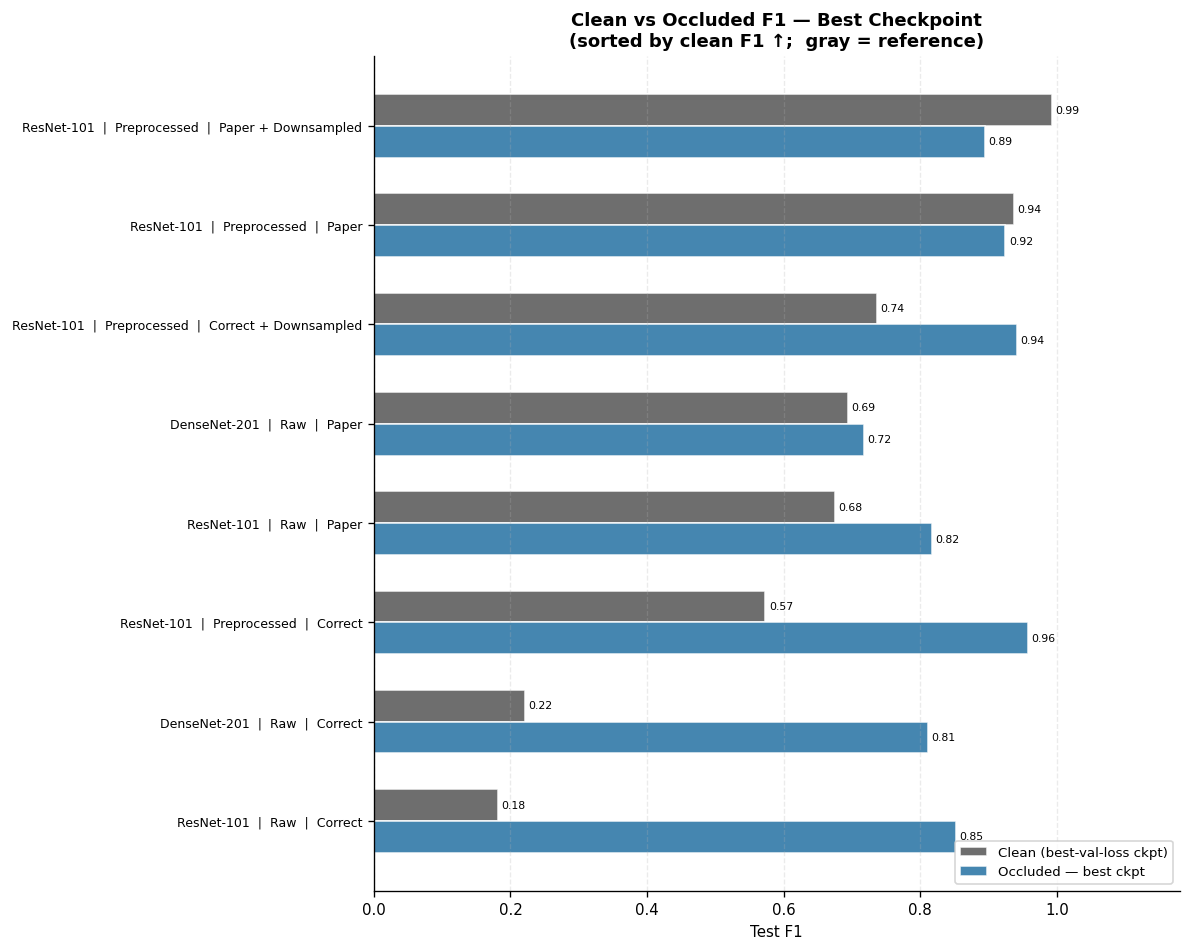

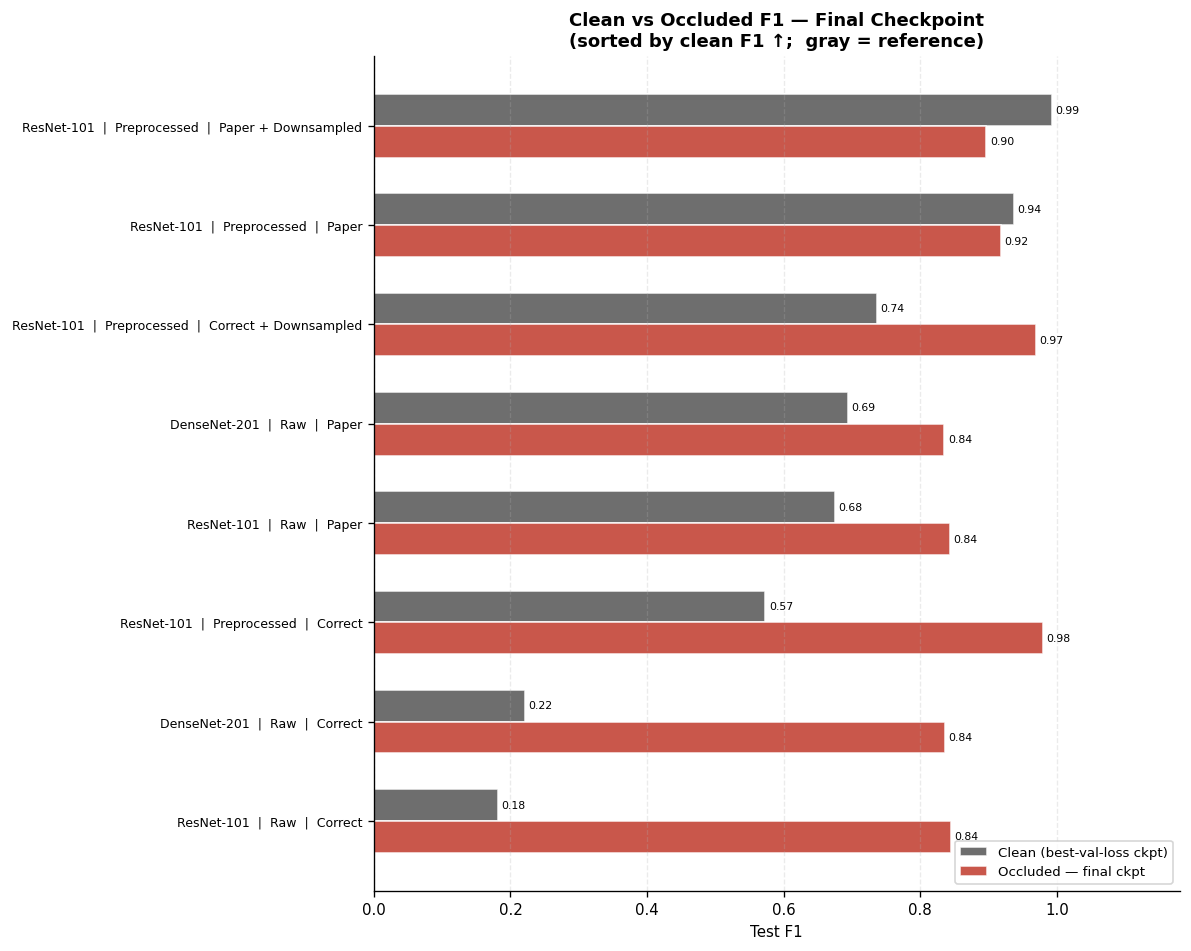

In [27]:
drop_records = []
for ckpt_name, abl_row in df_abl.iterrows():
    model     = abl_row["model"]
    data      = abl_row["data"]
    mode      = abl_row["mode"]
    ckpt_type = abl_row["ckpt_type"]

    run_key = None
    for k in summary.index:
        if _match_run(k, model, data, mode):
            run_key = k
            break

    if run_key is None:
        continue

    drop_records.append({
        "run":         run_key,
        "ckpt_type":   ckpt_type,
        "clean_f1":    summary.loc[run_key, "test_f1"],
        "occluded_f1": abl_row["f1_score"],
    })

if not drop_records:
    print("No matching training runs found for drop analysis.")
else:
    df_drop = pd.DataFrame(drop_records)

    df_piv = df_drop.pivot_table(
        index="run", columns="ckpt_type", values="occluded_f1", aggfunc="first"
    )
    df_piv["clean"] = (
        df_drop.drop_duplicates("run").set_index("run")["clean_f1"]
    )
    df_piv = df_piv.sort_values("clean", ascending=True)

    n      = len(df_piv)
    height = 0.32
    y      = np.arange(n)

    for ckpt_col, ckpt_label, ckpt_color, title in [
        ("best",  "Occluded — best ckpt",  "#2471A3", "Clean vs Occluded F1 — Best Checkpoint"),
        ("final", "Occluded — final ckpt", "#C0392B", "Clean vs Occluded F1 — Final Checkpoint"),
    ]:
        if ckpt_col not in df_piv.columns:
            continue

        fig, ax = plt.subplots(figsize=(10, max(5, n * 1.0)))

        clean_bars = ax.barh(
            y + height / 2, df_piv["clean"], height,
            label="Clean (best-val-loss ckpt)",
            color="#555555", alpha=0.85, edgecolor="white",
        )
        ax.bar_label(clean_bars, fmt="%.2f", label_type="edge", fontsize=6.5, padding=2)

        occ_bars = ax.barh(
            y - height / 2, df_piv[ckpt_col], height,
            label=ckpt_label,
            color=ckpt_color, alpha=0.85, edgecolor="white",
        )
        ax.bar_label(occ_bars, fmt="%.2f", label_type="edge", fontsize=6.5, padding=2)

        ax.set_yticks(y)
        ax.set_yticklabels(df_piv.index, fontsize=7.5)
        ax.set_xlim(0, 1.18)
        ax.set_xlabel("Test F1")
        ax.set_title(
            title + "\n(sorted by clean F1 ↑;  gray = reference)",
            fontweight="bold",
        )
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(axis="x", linestyle="--", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        fig.savefig(METRIC_CURVES_DIR / f"clean_vs_occluded_f1_{ckpt_col}.png", dpi=150, bbox_inches="tight")
        plt.show()

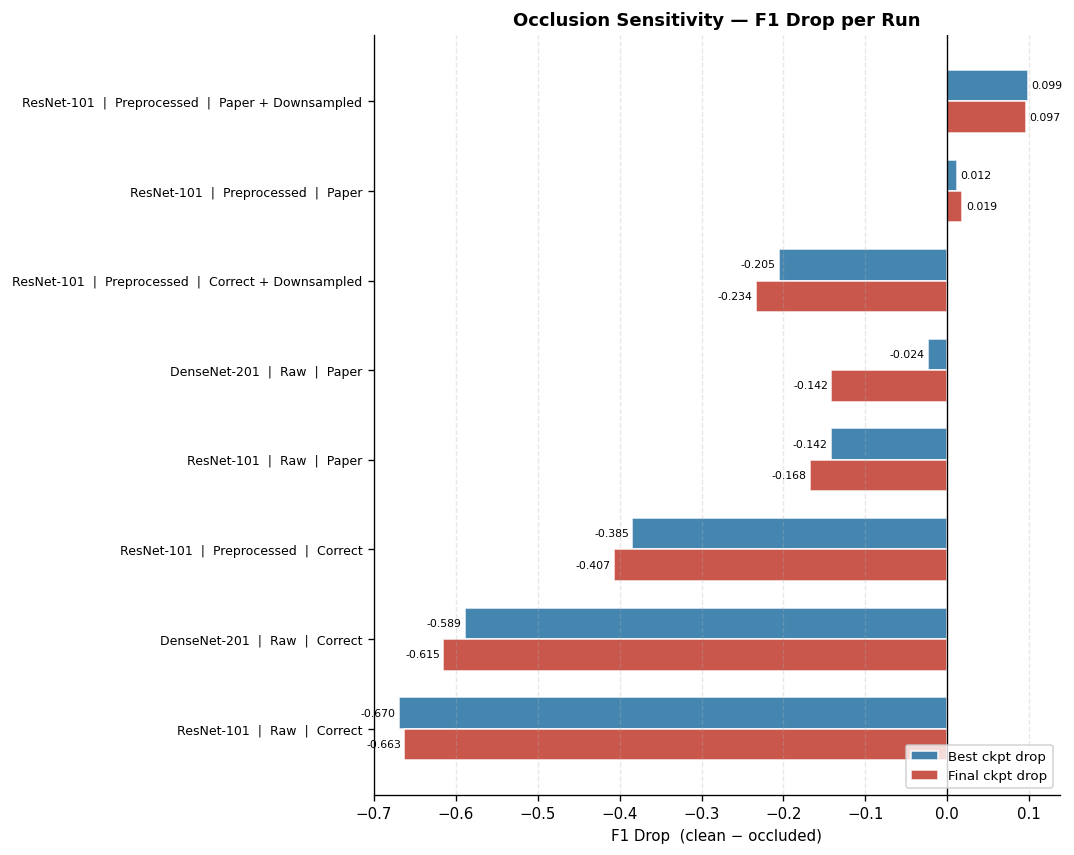

In [28]:
# ── F1 drop: clean − occluded, showing occlusion sensitivity per run ──────────────────
df_drop_delta = pd.DataFrame({
    "Best ckpt drop":  df_piv["clean"] - df_piv.get("best",  pd.Series(dtype=float, index=df_piv.index)),
    "Final ckpt drop": df_piv["clean"] - df_piv.get("final", pd.Series(dtype=float, index=df_piv.index)),
}).dropna(how="all")
# Preserve the sort order from df_piv (ascending clean F1 → best at top)
df_drop_delta = df_drop_delta.reindex(df_piv.index)

n      = len(df_drop_delta)
y      = np.arange(n)
height = 0.35

fig, ax = plt.subplots(figsize=(9, max(4, n * 0.9)))

if "Best ckpt drop" in df_drop_delta.columns:
    ax.barh(y + height / 2, df_drop_delta["Best ckpt drop"], height,
            label="Best ckpt drop", color="#2471A3", alpha=0.85, edgecolor="white")
if "Final ckpt drop" in df_drop_delta.columns:
    ax.barh(y - height / 2, df_drop_delta["Final ckpt drop"], height,
            label="Final ckpt drop", color="#C0392B", alpha=0.85, edgecolor="white")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f", label_type="edge", fontsize=6.5, padding=2)

ax.set_yticks(y)
ax.set_yticklabels(df_drop_delta.index, fontsize=7.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(left=-0.7)
ax.set_xlabel("F1 Drop  (clean − occluded)")
ax.set_title(
    "Occlusion Sensitivity — F1 Drop per Run",
    fontweight="bold",
)
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(METRIC_CURVES_DIR / "occlusion_sensitivity_f1_drop.png", dpi=150, bbox_inches="tight")
plt.show()


> **Guha & Bhandage (2025)** addressed this by downsampling the HC class to match the PMG count (4,517 per class). The `balance_mode=pre_split` runs in this project replicate that approach; `post_split` is the methodologically correct alternative.